In [1]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

## general solution for g(t)

In [2]:
from mpmath import *
def gamma_t(time, const, plot=0, form=0):
    center = (time[0] + time[-1]) / 2
    def Li_2(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_3(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_4(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_5(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_6(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    if form==0:
        top = (const/2)/(np.cosh(const*(time-center)))**2
        bottom = 1-(1/2)*(np.tanh(const*(time-center))-np.tanh(const*(time[0]-center)))
    elif form==1:                                                      
        top = (6*const**3/np.pi**2)*(time-center)**2/(np.cosh(const*(time-center)))**2
        def f(t):
            return 6 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) / np.pi**2
        bottom = 1-(f(const*(time-center))-f(const*(time[0]-center)))
    elif form==2:                                                    
        top = (45*const**5/2/np.pi**4) * ((time-center)**2 - (np.pi/const)**2/12)**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_2 = 6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1)
            f_1 = -np.pi**2 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) /6
            f_0 = np.pi**4*np.tanh(t)/144
            return 45*(f_2 + f_1 + f_0)/2/np.pi**4
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    elif form==3:
        top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
            f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
            f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
            return 350*(f_3 + f_2 + f_1)/9/np.pi**6
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    if plot:
        plt.figure(figsize=(6,2))
        plt.plot(time, top/bottom/2/np.pi)
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.show()
    return top/bottom/2/np.pi

In [3]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

# Define parameters
kappa = 2.5e-3*2*np.pi*2

# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

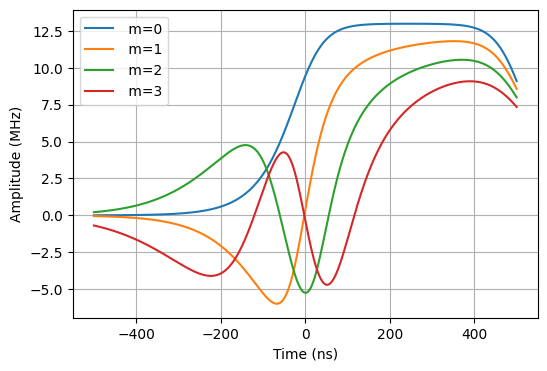

In [4]:

def f(t, m, kappa):
    return xi_m(t, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    

    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

kappa =  0.14*2*np.pi
kappa_ph = 2.5e-3*2*np.pi*2
t_vals = np.linspace(-500, 500, 501)

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


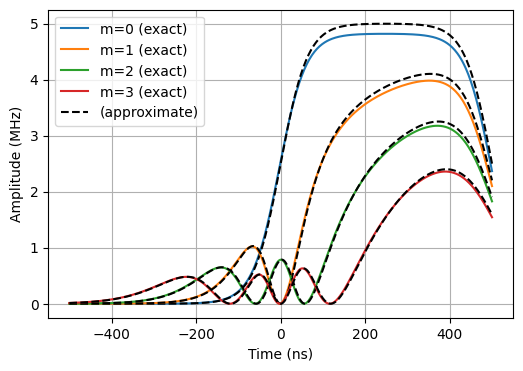

In [5]:
plt.figure(figsize=(6, 4))
for m in range(4):
    # print(t_vals, m, kappa, kappa_ph)
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, 4*g_vals**2/kappa/2/np.pi*1e3, label=fr"m={m} (exact)")
    Gamma_ana = gamma_t(t_vals, kappa_ph / 2, form=m)
    if m == 3:
        plt.plot(t_vals, Gamma_ana*1e3, linestyle='--', color="black", label="(approximate)")
    else:
        plt.plot(t_vals, Gamma_ana*1e3, linestyle='--', color="black")


plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()

## QuTiP simulation

In [6]:
from process_tomography import *
from state_tomography import *
from libys import qtp as ysq
from datataking import search_datadict_miyamura
from qutip import fidelity, Qobj
from analysis import (
    SpatiotemporalAnalysis,demodulate
)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


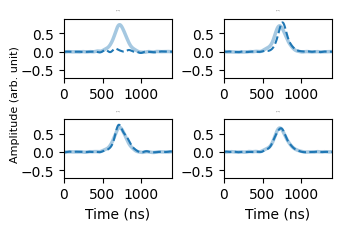

In [7]:
result_dict_tx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124754", duration=1000),
    data_ph1 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124137", duration=1000),
    data_ph2 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124227", duration=1000),
    data_ph3 = dict(target_freq=9.38, date="2025-08-12", acquire_time="125025", duration=1000),
)
result_dict_rx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110853", duration=1000),
    data_ph1 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110223", duration=1000),
    data_ph2 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110313", duration=1000),
    data_ph3 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110403", duration=1000),
)

num_of_ph_amp = 1
num_of_fogi_timing = 51
f_if = (9.5-9.38)*1e9

header = "C:/Users/qipe/Documents/qutip_simulation/codes/data/CDK184/"
ph0_fo0 = "/2025-08-13/2025-08-13T081809_9c21d1b7-j1_JPA_comm_timing"
ph0_fo1 = "/2025-08-12/2025-08-12T145332_addb4dad-j1_JPA_comm_timing"
ph0_fo2 = "/2025-08-12/2025-08-12T223011_78afd813-j1_JPA_comm_timing"
ph0_fo3 = "/2025-08-12/2025-08-12T162316_371a7ee5-j1_JPA_comm_timing"
ph1_fo0 = "/2025-08-12/2025-08-12T205345_fff72f75-j1_JPA_comm_timing"
ph1_fo1 = "/2025-08-12/2025-08-12T214421_11bce74b-j1_JPA_comm_timing"
ph1_fo2 = "/2025-08-12/2025-08-12T183812_10814b2f-j1_JPA_comm_timing"
ph1_fo3 = "/2025-08-12/2025-08-12T192312_59d17cb7-j1_JPA_comm_timing"
ph2_fo0 = "/2025-08-12/2025-08-12T200813_a3f91ff0-j1_JPA_comm_timing"
ph2_fo1 = "/2025-08-13/2025-08-13T010923_b6800336-j1_JPA_comm_timing"
ph2_fo2 = "/2025-08-13/2025-08-13T015414_fa4288d4-j1_JPA_comm_timing"
ph2_fo3 = "/2025-08-13/2025-08-13T023907_3f311ad9-j1_JPA_comm_timing"
ph3_fo0 = "/2025-08-13/2025-08-13T032400_84bc5ae9-j1_JPA_comm_timing"
ph3_fo1 = "/2025-08-13/2025-08-13T040856_cb5ba4f9-j1_JPA_comm_timing"
ph3_fo2 = "/2025-08-13/2025-08-13T045352_12672ec9-j1_JPA_comm_timing"
ph3_fo3 = "/2025-08-13/2025-08-13T053850_5a9232a6-j1_JPA_comm_timing"

acquisition_00 = SpatiotemporalAnalysis(header, ph0_fo0, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_01 = SpatiotemporalAnalysis(header, ph0_fo1, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_02 = SpatiotemporalAnalysis(header, ph0_fo2, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_03 = SpatiotemporalAnalysis(header, ph0_fo3, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_10 = SpatiotemporalAnalysis(header, ph1_fo0, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_11 = SpatiotemporalAnalysis(header, ph1_fo1, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_12 = SpatiotemporalAnalysis(header, ph1_fo2, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_13 = SpatiotemporalAnalysis(header, ph1_fo3, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_20 = SpatiotemporalAnalysis(header, ph2_fo0, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_21 = SpatiotemporalAnalysis(header, ph2_fo1, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_22 = SpatiotemporalAnalysis(header, ph2_fo2, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_23 = SpatiotemporalAnalysis(header, ph2_fo3, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_30 = SpatiotemporalAnalysis(header, ph3_fo0, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_31 = SpatiotemporalAnalysis(header, ph3_fo1, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_32 = SpatiotemporalAnalysis(header, ph3_fo2, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_33 = SpatiotemporalAnalysis(header, ph3_fo3, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

ph_amp = 0
fogi_freq = 17
fig, axs = plt.subplots(2, 2, figsize=(3.2, 2.2) , constrained_layout=True) 
acquisition_00.plot_waveform(ax=axs[0, 0], title="(0, 0)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
acquisition_01.plot_waveform(ax=axs[0, 1], title="(0, 1)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
acquisition_02.plot_waveform(ax=axs[1, 0], title="(0, 2)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
acquisition_03.plot_waveform(ax=axs[1, 1], title="(0, 3)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq, show_title=False, mode=0)
fig.text(-0.02, 0.55, "Amplitude (arb. unit)", va="center", rotation="vertical")
for ax in axs[-1, :]:
    ax.set_xlabel("Time (ns)")
# plt.tight_layout()
plt.show()

In [ ]:
n_cutoff_A = 3
n_cutoff_B = 3
n_cutoff_rA = 2
n_cutoff_rB = 2

b_A = qt.tensor(qt.destroy(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
b_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.destroy(n_cutoff_B))
a_A = qt.tensor(qt.qeye(n_cutoff_A), qt.destroy(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
a_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.destroy(n_cutoff_rB), qt.qeye(n_cutoff_B))

zeromatrixxtmp=np.zeros([n_cutoff_A, n_cutoff_A])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog_A = qt.tensor(gedecayop, qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
etog_B = qt.tensor(qt.qeye(n_cutoff_B), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), gedecayop)
zeromatrixxtmp=np.zeros([n_cutoff_A, n_cutoff_A])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe_A = qt.tensor(efdecayop, qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
ftoe_B = qt.tensor(qt.qeye(n_cutoff_B), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), efdecayop)
zeromatrixxtmp=np.zeros([n_cutoff_A, n_cutoff_A])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge_A = qt.tensor(gedechoop, qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
dechoge_B = qt.tensor(qt.qeye(n_cutoff_B), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), gedechoop)
zeromatrixxtmp=np.zeros([n_cutoff_A, n_cutoff_A])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef_A = qt.tensor(efdechoop, qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
dechoef_B = qt.tensor(qt.qeye(n_cutoff_B), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), efdechoop)

g0_A = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
g0_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
f0_A = qt.tensor(qt.basis(n_cutoff_A, 2), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
g1_A = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 1), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
f0_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 2))
g1_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 1), qt.basis(n_cutoff_B, 0))
e0_A = qt.tensor(qt.basis(n_cutoff_A, 1), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
e0_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 1))

alpha_A = -0.356 * 2 * np.pi
chi_A = -0.0076 * 2 * np.pi
alpha_B = -0.356 * 2 * np.pi
chi_B = -0.004 * 2 * np.pi
eta = 0.67
kappa_A = 0.14 * 2 * np.pi
kappa_B = 0.16 * 2 * np.pi
K_A = 0 * 2 * np.pi
K_B = 0 * 2 * np.pi

H_fogi_A = (
    -alpha_A / 2 * b_A.dag()*b_A + alpha_A * b_A.dag()*b_A.dag()*b_A*b_A / 2
    +K_A * a_A.dag()*a_A.dag()*a_A*a_A / 2 + 2*chi_A*a_A.dag()*a_A*b_A.dag()*b_A
)

H_fogi_B = (
    -alpha_B / 2 * b_B.dag()*b_B + alpha_B * b_B.dag()*b_B.dag()*b_B*b_B / 2
    +K_B * a_B.dag()*a_B.dag()*a_B*a_B / 2+2*chi_B*a_B.dag()*a_B*b_B.dag()*b_B
)

H_c = 1j * np.sqrt(eta) * (np.sqrt(kappa_A*kappa_B)/2) * (a_A.dag()*a_B - a_A*a_B.dag())

H_d_A = -a_A*b_A.dag()*b_A.dag()/np.sqrt(2)
H_d_B = -a_B*b_B.dag()*b_B.dag()/np.sqrt(2) 


T1ge_A=29*1e3
T1ge_B=19*1e3
T1ef_A=22*1e3
T1ef_B=11*1e3
T2ge_A=5*1e3
T2ge_B=9*1e3
T2ef_A=5*1e3
T2ef_B=7*1e3
Tphige_A=1/((1/T2ge_A-1/T1ge_A/2)/2)
Tphige_B=1/((1/T2ge_B-1/T1ge_B/2)/2)
Tphief_A=1/((1/T2ef_A-1/T1ef_A/2)/2)
Tphief_B=1/((1/T2ef_B-1/T1ef_B/2)/2)

c_ops = [np.sqrt(kappa_A*eta)*a_A + np.sqrt(kappa_B)*a_B, np.sqrt(kappa_A*(1-eta))*a_A,
        np.sqrt(1/T1ge_A)*etog_A, np.sqrt(1/T1ge_B)*etog_B, np.sqrt(1/T1ef_A)*ftoe_A, np.sqrt(1/T1ef_B)*ftoe_B, 
        np.sqrt(1/Tphige_A)*dechoge_A, np.sqrt(1/Tphige_B)*dechoge_B, np.sqrt(1/Tphief_A)*dechoef_A, np.sqrt(1/Tphief_B)*dechoef_B]

e_ops = [g0_B*g1_B.dag()]
e_labels = ["|g0><g1|"]
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=False)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


%%%%%%%%%%%%%%%
 Sender mode: 0


c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   1.91s. Est. time left: 00:00:00:17
20.0%. Run time:   3.74s. Est. time left: 00:00:00:14
30.0%. Run time:   5.20s. Est. time left: 00:00:00:12
40.0%. Run time:   6.33s. Est. time left: 00:00:00:09
50.0%. Run time:   7.53s. Est. time left: 00:00:00:07
60.0%. Run time:   8.66s. Est. time left: 00:00:00:05
70.0%. Run time:   9.81s. Est. time left: 00:00:00:04
80.0%. Run time:  10.99s. Est. time left: 00:00:00:02
90.0%. Run time:  12.19s. Est. time left: 00:00:00:01
100.0%. Run time:  13.34s. Est. time left: 00:00:00:00
Total run time:  13.34s
10.0%. Run time:   1.28s. Est. time left: 00:00:00:11
20.0%. Run time:   2.47s. Est. time left: 00:00:00:09
30.0%. Run time:   3.67s. Est. time left: 00:00:00:08
40.0%. Run time:   4.91s. Est. time left: 00:00:00:07
50.0%. Run time:   6.08s. Est. time left: 00:00:00:06
60.0%. Run time:   7.32s. Est. time left: 00:00:00:04
70.0%. Run time:   8.50s. Est. time left: 00:00:00:03
80.0%. Run time:   9.71s. Est. time left: 00:00:00:02
90.

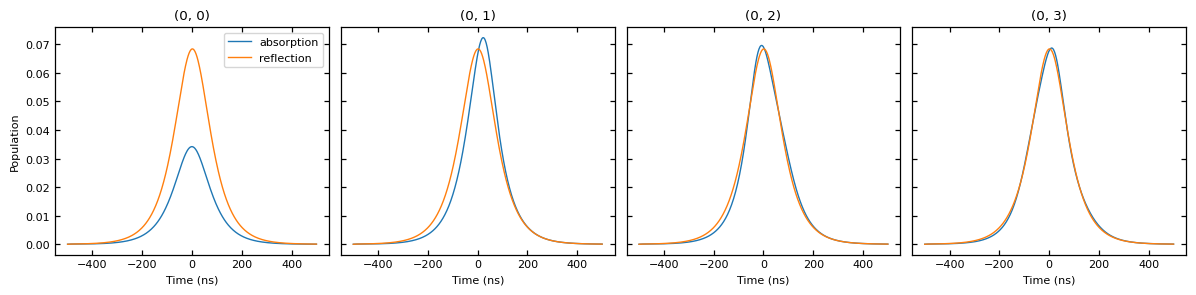

%%%%%%%%%%%%%%%
 Sender mode: 1
10.0%. Run time:   1.13s. Est. time left: 00:00:00:10
20.0%. Run time:   2.21s. Est. time left: 00:00:00:08
30.0%. Run time:   3.35s. Est. time left: 00:00:00:07
40.0%. Run time:   4.81s. Est. time left: 00:00:00:07
50.0%. Run time:   5.88s. Est. time left: 00:00:00:05
60.0%. Run time:   7.00s. Est. time left: 00:00:00:04
70.0%. Run time:   8.50s. Est. time left: 00:00:00:03
80.0%. Run time:  10.39s. Est. time left: 00:00:00:02
90.0%. Run time:  11.95s. Est. time left: 00:00:00:01
100.0%. Run time:  13.45s. Est. time left: 00:00:00:00
Total run time:  13.46s
10.0%. Run time:   2.04s. Est. time left: 00:00:00:18
20.0%. Run time:   3.84s. Est. time left: 00:00:00:15
30.0%. Run time:   4.98s. Est. time left: 00:00:00:11
40.0%. Run time:   6.11s. Est. time left: 00:00:00:09
50.0%. Run time:   7.22s. Est. time left: 00:00:00:07
60.0%. Run time:   8.41s. Est. time left: 00:00:00:05
70.0%. Run time:   9.53s. Est. time left: 00:00:00:04
80.0%. Run time:  11.09s.

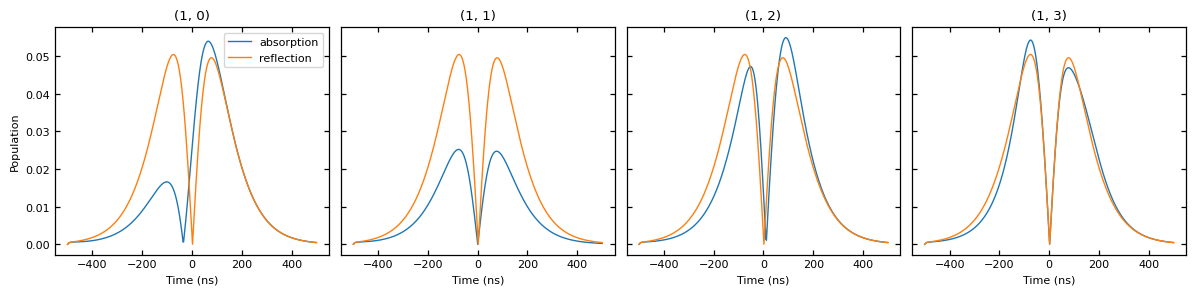

%%%%%%%%%%%%%%%
 Sender mode: 2
10.0%. Run time:   1.09s. Est. time left: 00:00:00:09
20.0%. Run time:   2.12s. Est. time left: 00:00:00:08
30.0%. Run time:   3.15s. Est. time left: 00:00:00:07
40.0%. Run time:   4.32s. Est. time left: 00:00:00:06
50.0%. Run time:   5.33s. Est. time left: 00:00:00:05
60.0%. Run time:   6.38s. Est. time left: 00:00:00:04
70.0%. Run time:   7.52s. Est. time left: 00:00:00:03
80.0%. Run time:   8.58s. Est. time left: 00:00:00:02
90.0%. Run time:   9.71s. Est. time left: 00:00:00:01
100.0%. Run time:  11.08s. Est. time left: 00:00:00:00
Total run time:  11.08s
10.0%. Run time:   1.16s. Est. time left: 00:00:00:10
20.0%. Run time:   2.29s. Est. time left: 00:00:00:09
30.0%. Run time:   3.50s. Est. time left: 00:00:00:08
40.0%. Run time:   4.80s. Est. time left: 00:00:00:07
50.0%. Run time:   5.99s. Est. time left: 00:00:00:05
60.0%. Run time:   7.15s. Est. time left: 00:00:00:04
70.0%. Run time:   8.34s. Est. time left: 00:00:00:03
80.0%. Run time:   9.47s.

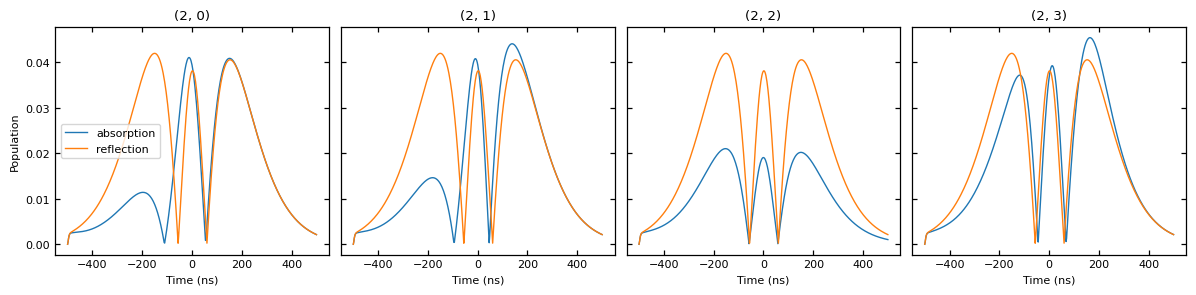

%%%%%%%%%%%%%%%
 Sender mode: 3
10.0%. Run time:   2.00s. Est. time left: 00:00:00:17
20.0%. Run time:   3.67s. Est. time left: 00:00:00:14
30.0%. Run time:   6.02s. Est. time left: 00:00:00:14
40.0%. Run time:   8.84s. Est. time left: 00:00:00:13
50.0%. Run time:  10.45s. Est. time left: 00:00:00:10
60.0%. Run time:  11.61s. Est. time left: 00:00:00:07
70.0%. Run time:  13.71s. Est. time left: 00:00:00:05
80.0%. Run time:  14.92s. Est. time left: 00:00:00:03
90.0%. Run time:  16.08s. Est. time left: 00:00:00:01
100.0%. Run time:  17.32s. Est. time left: 00:00:00:00
Total run time:  17.32s
10.0%. Run time:   1.23s. Est. time left: 00:00:00:11
20.0%. Run time:   2.61s. Est. time left: 00:00:00:10
30.0%. Run time:   4.02s. Est. time left: 00:00:00:09
40.0%. Run time:   5.31s. Est. time left: 00:00:00:07
50.0%. Run time:   6.52s. Est. time left: 00:00:00:06
60.0%. Run time:   7.80s. Est. time left: 00:00:00:05
70.0%. Run time:   9.00s. Est. time left: 00:00:00:03
80.0%. Run time:  10.26s.

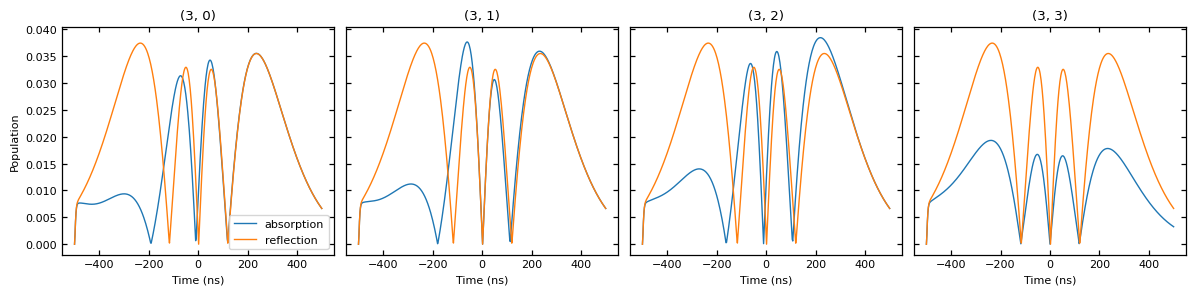

In [22]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 500 
N = 501
tgrid = np.linspace(-T, T, N)
dt = tgrid[1] - tgrid[0]
kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

gA_interps = []
gB_interps = []

for m in range(4):  
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    numerator_A = f_prime_vals + (kappa_A * f_vals / 2)
    denominator_A = np.sqrt(kappa_A * (1.0 - integral_vals) - f2_vals)
    gA_vals = numerator_A / denominator_A
    gA_interp = interp1d(tgrid, np.real(gA_vals), kind='cubic', fill_value='extrapolate')
    gA_interps.append(gA_interp)

    numerator_B = f_prime_vals + (kappa_B * f_vals / 2)
    denominator_B = np.sqrt(kappa_B * (1.0 - integral_vals) - f2_vals)
    gB_vals = numerator_B / denominator_B
    gB_interp = interp1d(tgrid, np.real(gB_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    gB_interps.append(gB_interp)


def g_time_A(t, args):
    t_local = float(t) - float(args["center_A"])
    m = int(args["mode_num_A"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["gA_interps"][m](t_local))

def g_time_B(t, args):
    # t_local = float(t) - float(args["center_B"])
    t_local = float(t) - float(args["center_B"])
    m = int(args["mode_num_B"])
    return float(args["gB_interps"][m](t_local))

def g_time_A_conj(t, args):
    return np.conjugate(g_time_A(t, args))

def g_time_B_conj(t, args):
    return np.conjugate(g_time_B(t, args))


psi0 = (g0_A + f0_A).unit()

base_args = {
    "center_A": 0.0,
    "center_B": 0.0,
    "mode_num_A": 0,
    "mode_num_B": 0,
    "gA_interps": gA_interps,
    "gB_interps": gB_interps
}

H = [
    H_fogi_A + H_fogi_B + H_c,
    [H_d_A, g_time_A], [H_d_A.dag(), g_time_A_conj],
    [H_d_B, g_time_B], [H_d_B.dag(), g_time_B_conj]
]

H_wo_abs = [
    H_fogi_A + H_fogi_B + H_c,
    [H_d_A, g_time_A], [H_d_A.dag(), g_time_A_conj]
]

mode_to_run = 0
args_run = base_args.copy()
args_run["mode_num"] = mode_to_run

results_abs = []
results_wo_abs = []
for mode_num_A in range(4):
    m_A = mode_num_A
    args_run = base_args.copy()
    args_run["mode_num_A"] = m_A
    args_run["mode_num_B"] = m_A
    print(f"%%%%%%%%%%%%%%%")
    print(f" Sender mode: {m_A}")
    result_wo_abs = qt.mesolve(
            H_wo_abs, psi0, tgrid, c_ops, e_ops=e_ops,
            args=args_run, options=options, progress_bar=True
        )
    results_wo_abs.append(result_wo_abs)
    fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharex=True, sharey=True)
    axes = axes.flatten()
    results=[]
    for mode_num_B in range(4):
        m_B = mode_num_B
        args_run["mode_num_B"] = m_B
        result = qt.mesolve(
            H, psi0, tgrid, c_ops, e_ops=e_ops,
            args=args_run, options=options, progress_bar=True
        )
        results.append(result)
        ax = axes[m_B]
        for i, l in enumerate(e_labels):
            ax.plot(tgrid, np.abs(result.expect[i]), label="absorption")
            ax.plot(tgrid, np.abs(result_wo_abs.expect[i]), label="reflection")
        ax.set_title(f"({m_A}, {m_B})")
        ax.set_xlabel("Time (ns)")
        if m_B == 0:
            ax.set_ylabel("Population")
            ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    results_abs.append(results)


In [ ]:
from scipy import interpolate, optimize
from scipy.ndimage import shift as nd_shift

def fit_waveform(time, waveform_exp, waveform_sim, x0=[1.0, 0.0]):

    def func(params):
        scale, shift = params
        sim_shifted = roll_with_interpolation(waveform_sim, shift=-shift)
        return scale * sim_shifted

    def cost_func(params):
        return np.linalg.norm(np.abs(func(params)) - np.abs(waveform_exp))

    best_x = optimize.minimize(cost_func, x0, method='Nelder-Mead').x
    print("best_x:", best_x)

    fitted = func(best_x)
    return fitted, best_x

def roll_with_interpolation(array, shift):
    return nd_shift(array, shift=shift, mode='constant', cval=0.0)

In [ ]:
acquisitions = [[None for _ in range(4)] for _ in range(4)]

acquisitions[0][0] = acquisition_00
acquisitions[0][1] = acquisition_01
acquisitions[0][2] = acquisition_02
acquisitions[0][3] = acquisition_03

acquisitions[1][0] = acquisition_10
acquisitions[1][1] = acquisition_11
acquisitions[1][2] = acquisition_12
acquisitions[1][3] = acquisition_13

acquisitions[2][0] = acquisition_20
acquisitions[2][1] = acquisition_21
acquisitions[2][2] = acquisition_22
acquisitions[2][3] = acquisition_23

acquisitions[3][0] = acquisition_30
acquisitions[3][1] = acquisition_31
acquisitions[3][2] = acquisition_32
acquisitions[3][3] = acquisition_33

best_x: [-1.09660090e-02 -1.18137585e+01]
best_x: [-1.07613711e-02 -1.46410345e+01]
best_x: [-1.00352087e-02 -1.15913362e+01]
best_x: [-9.91234289e-03 -1.39804715e+01]


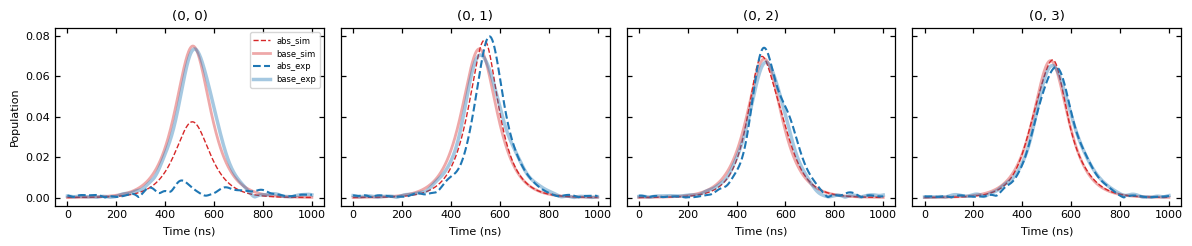

best_x: [-1.00552999e-02 -1.26569712e+01]
best_x: [-9.47966180e-03 -1.07441687e+01]
best_x: [-1.09394525e-02 -1.35939891e+01]
best_x: [-1.05125587e-02 -1.27302253e+01]


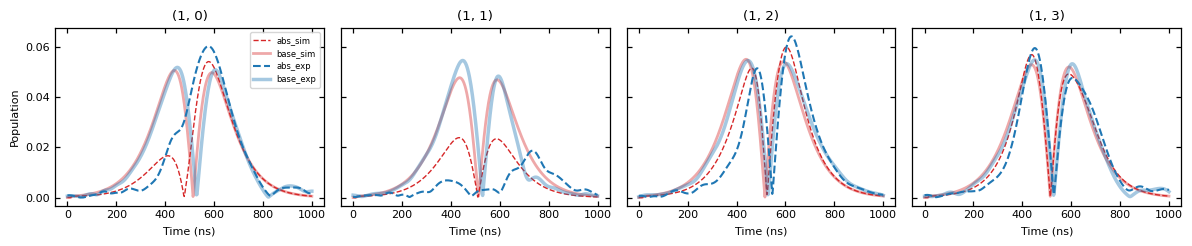

best_x: [-1.01795643e-02 -1.32181789e+01]
best_x: [-1.10369453e-02 -1.33434206e+01]
best_x: [-1.12509057e-02 -1.35273685e+01]
best_x: [-1.02491595e-02 -1.31592121e+01]


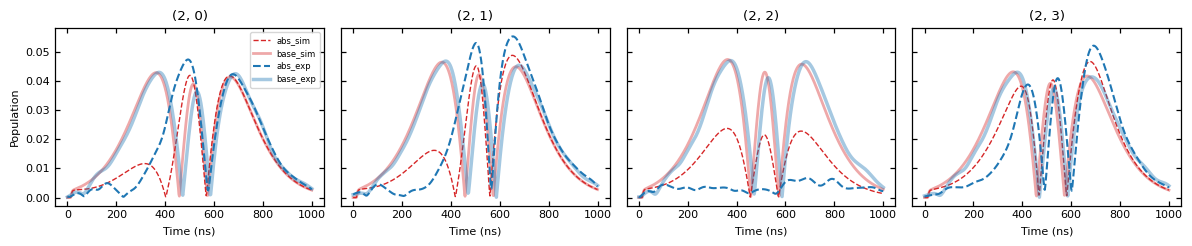

best_x: [ 1.18366707e-02 -1.43647436e+01]
best_x: [ 1.02020414e-02 -1.34159444e+01]
best_x: [ 1.13548782e-02 -1.37977051e+01]
best_x: [ 9.63923285e-03 -1.32180174e+01]


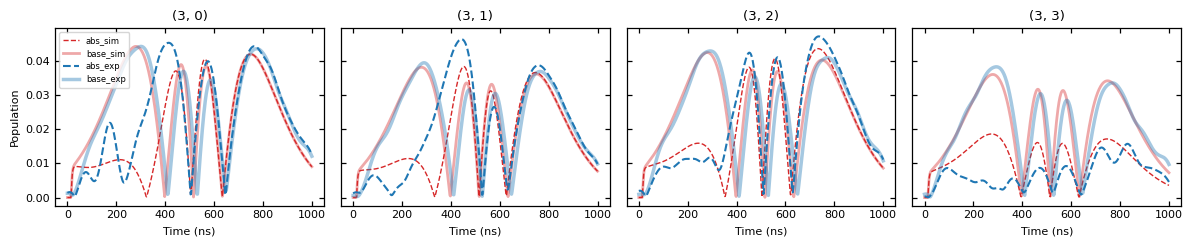

In [ ]:
from scipy.ndimage import shift as nd_shift

for m_A in range(4):
    fig, axes = plt.subplots(1, 4, figsize=(12, 2.5), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for m_B in range(4):
        ax = axes[m_B]
        for i, l in enumerate(e_labels):
            abs_sim = np.abs(results_abs[m_A][m_B].expect[i])
            base_sim = np.abs(results_wo_abs[m_A].expect[i])

            time = acquisitions[m_A][m_B].get_results()["time"][ph_amp][fogi_freq][100:-149]
            abs_exp = acquisitions[m_A][m_B].get_results()["y_absorbed_signals"][ph_amp][fogi_freq][100:-149]
            base_exp = acquisitions[m_A][m_B].get_results()["y_base_signals"][ph_amp][fogi_freq][100:-149]

            fitted_dummy, best_x = fit_waveform(time, base_exp, base_sim, x0=[1.0, 10.0])
            scale, shift_val = best_x
            
            def apply_fit(waveform, scale, shift_val, time):
                # waveform を時間軸に合わせてリサンプリング
                waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
                
                # shift_val をサンプル単位に変換
                dt = time[1] - time[0]
                shift_idx = -shift_val / dt  # 最適化で求めた shift が時間単位なら

                # nd_shift でシフト
                return scale * nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)

            
            fitted_abs_sim = apply_fit(abs_sim, scale, shift_val, time)
            fitted_base_sim = apply_fit(base_sim, scale, shift_val, time)
            
            ax.plot(time-200, np.abs(fitted_abs_sim)*100,lw=1, color="tab:red", linestyle="--", label="abs_sim")
            ax.plot(time-200, np.abs(fitted_base_sim)*100,lw=2, alpha=0.4, color="tab:red", label="base_sim")
            ax.plot(time-200, np.abs(abs_exp)*100, lw=1.5, color="tab:blue", linestyle="--", label="abs_exp")
            ax.plot(time-200, np.abs(base_exp)*100, lw=2.5, alpha=0.4, color="tab:blue", label="base_exp")


        ax.set_title(f"({m_A}, {m_B})")
        ax.set_xlabel("Time (ns)")
        if m_B == 0:
            ax.set_ylabel("Population")
            ax.legend(fontsize=6)
    plt.tight_layout()
    plt.show()


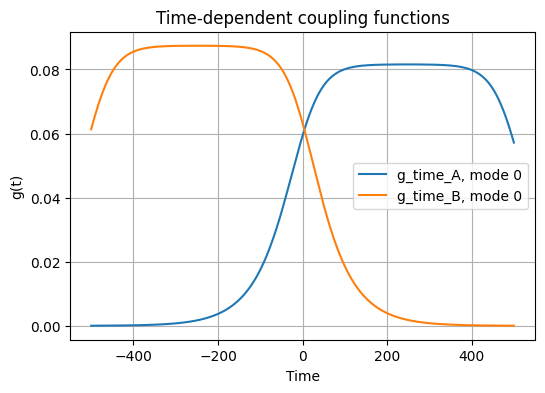

In [12]:
def g_time_A_vec(t_array, args):
    t_local = np.array(t_array) - args["center_A"]
    m = int(args["mode_num"])
    return np.array([float(args["gA_interps"][m](ti)) for ti in t_local])

def g_time_B_vec(t_array, args):
    t_local = (np.array(t_array) - args["center_B"])
    m = int(args["mode_num"])
    return np.array([float(args["gB_interps"][m](ti)) for ti in t_local])

mode_to_plot = 0
args_run = base_args.copy()
args_run["mode_num"] = mode_to_plot

plt.figure(figsize=(6,4))
plt.plot(tgrid, g_time_A_vec(tgrid, args_run), label=f"g_time_A, mode {mode_to_plot}")
plt.plot(tgrid, g_time_B_vec(tgrid, args_run), label=f"g_time_B, mode {mode_to_plot}")
plt.xlabel("Time")
plt.ylabel("g(t)")
plt.title("Time-dependent coupling functions")
plt.legend()
plt.grid(True)
plt.show()
